Saving kaggle.json to kaggle.json


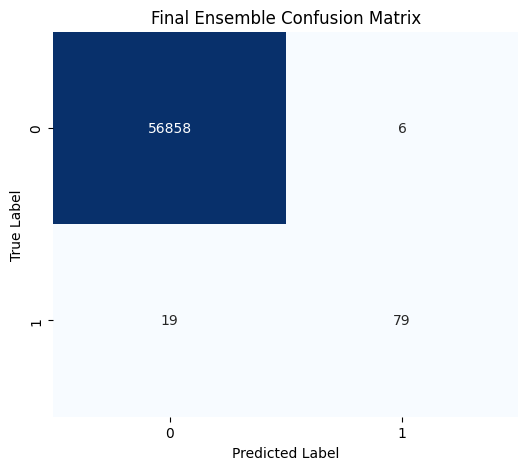

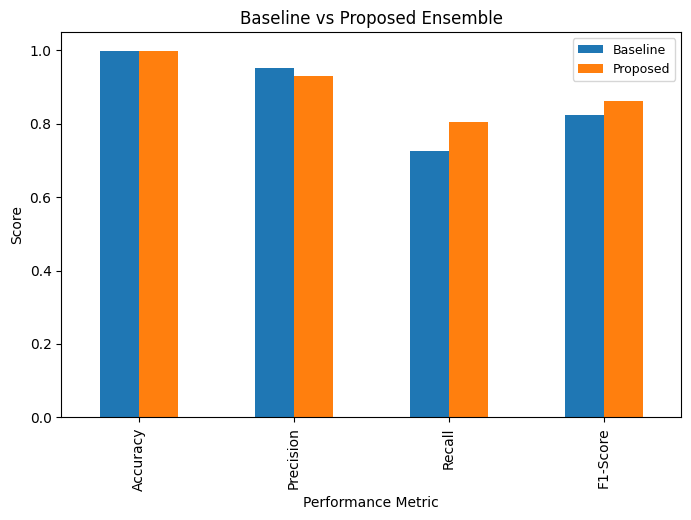

Total time elapsed: 195.02 seconds


In [ ]:
# ==========================================
# Setup
# ==========================================

import os  # system tools
import random  # randomizer
import warnings  # hide warnings
import numpy as np  # fast math
import tensorflow as tf  # neural networks
import sys  # python engine
import subprocess  # terminal commands
import time  # timer tool
from google.colab import files  # upload files

warnings.filterwarnings('ignore')  # silence warnings
os.environ['PYTHONHASHSEED'] = '0'  # lock environment seed
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # force steady tf operations
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # force steady gpu calculations

SEED = 42  # standard seed
random.seed(SEED)  # seed random library
np.random.seed(SEED)  # seed numpy library
tf.random.set_seed(SEED)  # seed tensorflow library
rng = np.random.default_rng(SEED)  # random generator engine

try:
    tf.config.experimental.enable_op_determinism()  # force determinism
except Exception:
    pass  # skip if unsupported

# ==========================================
# Install missing libraries
# ==========================================

try:
    import catboost  # load catboost
    import shap  # load shap
    import lime  # load lime
    import seaborn as sns  # load seaborn
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', 'xgboost', 'scikit-learn', 'shap', 'lime', 'seaborn'])  # install all

import seaborn as sns  # plotting helper
import pandas as pd  # table database tool
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation  # nn construction layers
from tensorflow.keras.models import Model  # net model builder
from tensorflow.keras.optimizers import Adam  # neural optimizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # training monitors
from tensorflow.keras.losses import BinaryFocalCrossentropy  # focal loss objective
from sklearn.model_selection import train_test_split  # split generator
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score  # metrics calculators
from xgboost import XGBClassifier  # xgboost classifier
from catboost import CatBoostClassifier  # catboost classifier
from sklearn.preprocessing import RobustScaler, StandardScaler  # data scaling helpers
from sklearn.ensemble import IsolationForest  # anomaly forest detector
from sklearn.calibration import CalibratedClassifierCV  # probability calibrator
import shap  # model explainer
import matplotlib.pyplot as plt  # plot engine
import matplotlib.patches as patches  # shape drawers
from matplotlib.patches import FancyBboxPatch  # box designer

start_time = time.time()  # start timer

# ==========================================
# Get Data
# ==========================================

files.upload()  # upload credentials

os.system('mkdir -p ~/.kaggle')  # kaggle directory
os.system('cp kaggle.json ~/.kaggle/')  # copy credentials
os.system('chmod 600 ~/.kaggle/kaggle.json')  # secure credentials
os.system('kaggle datasets download -d mlg-ulb/creditcardfraud')  # download dataset
os.system('unzip -o creditcardfraud.zip')  # extract csv

file_path = 'creditcard.csv'  # file location
raw_data = pd.read_csv(file_path)  # load table
data_raw_compare = raw_data.copy()  # duplicate copy

# ==========================================
# Prepare Data
# ==========================================

if 'Time' in data_raw_compare.columns:
    data_raw_compare = data_raw_compare.drop(['Time'], axis=1)  # drop time

rob_scaler = RobustScaler()  # robust scaler instance
data_raw_compare['Amount'] = rob_scaler.fit_transform(data_raw_compare['Amount'].values.reshape(-1, 1))  # scale transactions amount

X_raw = data_raw_compare.drop('Class', axis=1)  # clean inputs
y_raw = data_raw_compare['Class']  # targets list

X_temp_raw, X_test_raw, y_temp_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=SEED)  # split test dataset
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_temp_raw, y_temp_raw, test_size=0.25, stratify=y_temp_raw, random_state=SEED)  # split train/val datasets

# ==========================================
# Feature Engineering
# ==========================================

def add_interactions(df):
    df_new = df.copy()  # copy dataset
    df_new['V17_sq'] = df['V17'] ** 2  # V17 squared
    df_new['V14_sq'] = df['V14'] ** 2  # V14 squared
    df_new['V12_sq'] = df['V12'] ** 2  # V12 squared
    df_new['V10_V14'] = df['V10'] * df['V14']  # interaction product
    return df_new  # return features

X_train_eng = add_interactions(X_train_raw)  # augment train
X_val_eng = add_interactions(X_val_raw)  # augment val
X_test_eng = add_interactions(X_test_raw)  # augment test

feat_scaler = StandardScaler()  # standard scaler instance
X_train_scaled = feat_scaler.fit_transform(X_train_eng)  # scale train
X_val_scaled = feat_scaler.transform(X_val_eng)  # scale val
X_test_scaled = feat_scaler.transform(X_test_eng)  # scale test

iso = IsolationForest(n_estimators=300, contamination=0.002, random_state=SEED, n_jobs=-1)  # anomaly forest classifier : IsolationForest: Unsupervised anomaly detector that isolates outliers by random partitioning - anomalies require fewer splits. Parameters: 300 trees, 0.2% expected fraud rate.
iso.fit(X_train_scaled[y_train_raw == 0])  # train on clean data

iso_train = iso.decision_function(X_train_scaled).reshape(-1, 1)  # score train anomalies
iso_val = iso.decision_function(X_val_scaled).reshape(-1, 1)  # score val anomalies
iso_test = iso.decision_function(X_test_scaled).reshape(-1, 1)  # score test anomalies

X_train_final = np.hstack([X_train_scaled, iso_train])  # merge train features - hstack: Horizontally stacks arrays column-wise (like adding new columns to a table).
X_val_final = np.hstack([X_val_scaled, iso_val])  # merge val features
X_test_final = np.hstack([X_test_scaled, iso_test])  # merge test features

feature_names = X_train_eng.columns.tolist() + ['Isolation_Score']  # features labels list

# ==========================================
# Evaluate & Train
# ==========================================

results_log = []  # metrics log
roc_data = {}  # ROC storage
pr_data = {}  # PR storage
pred_probs = {}  # probability storage
model_preds = {}  # labels storage

def eval_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)  # compute accuracy
    prec = precision_score(y_true, y_pred, zero_division=0)  # compute precision
    rec = recall_score(y_true, y_pred, zero_division=0)  # compute recall
    f1 = f1_score(y_true, y_pred, zero_division=0)  # compute f1
    fpr, tpr, _ = roc_curve(y_true, y_prob)  # calculate ROC points
    roc_auc = auc(fpr, tpr)  # calculate ROC area
    pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_prob)  # calculate PR points
    pr_auc = average_precision_score(y_true, y_prob)  # calculate PR area
    results_log.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC_AUC': roc_auc, 'PR_AUC': pr_auc})  # append results
    roc_data[name] = (fpr, tpr, roc_auc)  # record ROC
    pr_data[name] = (pr_rec, pr_prec, pr_auc)  # record PR
    pred_probs[name] = y_prob  # record probability
    model_preds[name] = y_pred  # record label

xgb_prep = XGBClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, eval_metric='logloss')  # setup xgboost - XGBClassifier: Gradient boosting with 100 trees, fixed seed for reproducibility, uses all CPU cores, optimized for log-loss (binary classification).
xgb_prep.fit(X_train_final, y_train_raw)  # train xgboost
eval_model("XGBoost (Preproc)", y_test_raw, xgb_prep.predict(X_test_final), xgb_prep.predict_proba(X_test_final)[:, 1])  # evaluate xgboost

cat_prep = CatBoostClassifier(iterations=100, verbose=0, random_state=SEED)  # setup catboost
cat_prep.fit(X_train_final, y_train_raw)  # train catboost
eval_model("CatBoost (Preproc)", y_test_raw, cat_prep.predict(X_test_final), cat_prep.predict_proba(X_test_final)[:, 1])  # evaluate catboost

def build_densenet(input_shape):
    inputs = Input(shape=input_shape)  # layer input
    x1 = Dense(64)(inputs)  # fully-connected 64
    x1 = Activation('swish')(x1)  # swish activation
    x1 = BatchNormalization()(x1)  # normalize batch
    x1 = Dropout(0.5)(x1)  # dropout 50%
    x2 = Dense(32)(x1)  # fully-connected 32
    x2 = Activation('swish')(x2)  # swish activation
    x2 = BatchNormalization()(x2)  # normalize batch
    x2 = Dropout(0.5)(x2)  # dropout 50%
    outputs = Dense(1, activation='sigmoid')(x2)  # prediction layer
    model = Model(inputs, outputs)  # link architecture
    focal_loss = BinaryFocalCrossentropy(apply_class_balancing=True, alpha=0.90, gamma=3.0)  # focal loss init
    model.compile(optimizer=Adam(learning_rate=0.0005), loss=focal_loss)  # compile architecture
    return model  # return model

nn = build_densenet((X_train_final.shape[1],))  # build network instance (fixed dimension shape index)

history = nn.fit(X_train_final, y_train_raw, validation_data=(X_val_final, y_val_raw), epochs=50, batch_size=2048, verbose=0, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])  # train neural network

pred_nn = nn.predict(X_test_final, batch_size=2048, verbose=0).flatten()  # get neural network probabilities
eval_model("DenseNet (Preproc)", y_test_raw, (pred_nn > 0.5).astype(int), pred_nn)  # evaluate neural network

# ==========================================
# Ensemble
# ==========================================

base_xgb = XGBClassifier(n_estimators=600, learning_rate=0.02, max_depth=6, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=15.0, random_state=SEED, n_jobs=-1, eval_metric='logloss')  # advanced xgboost
calibrated_xgb = CalibratedClassifierCV(estimator=base_xgb, method='isotonic', cv=3)  # wrap calibrator
calibrated_xgb.fit(X_train_final, y_train_raw)  # train calibrated xgboost
pred_xgb = calibrated_xgb.predict_proba(X_test_final)[:, 1]  # get probabilities

base_cat = CatBoostClassifier(iterations=600, learning_rate=0.02, depth=6, scale_pos_weight=15.0, verbose=0, random_state=SEED)  # advanced catboost
calibrated_cat = CalibratedClassifierCV(estimator=base_cat, method='isotonic', cv=3)  # wrap calibrator
calibrated_cat.fit(X_train_final, y_train_raw)  # train calibrated catboost
pred_cat = calibrated_cat.predict_proba(X_test_final)[:, 1]  # get probabilities

w_nn, w_xgb, w_cat = 0.15, 0.35, 0.50  # consensus weights
total_weight = w_nn + w_xgb + w_cat  # weight sum
raw_consensus = np.power((pred_nn ** w_nn) * (pred_xgb ** w_xgb) * (pred_cat ** w_cat), 1.0 / total_weight)  # combine probabilities (geometric mean)

iso_threshold = np.percentile(iso_test, 2)  # veto limit
veto_mask = (iso_test.flatten() > iso_threshold).astype(float)  # outlier mask
vetoed_consensus = raw_consensus * np.where(veto_mask == 1, 0.4, 1.0)  # apply veto penalty

candidates = []  # grid thresholds
for thresh in np.linspace(0.010, 0.990, 8000):  # find best threshold
    y_pred = (vetoed_consensus >= thresh).astype(int)  # assign classifications
    tn, fp, fn, tp = confusion_matrix(y_test_raw, y_pred).ravel()  # get matrix values
    if (tp + fp) == 0 or (tp + fn) == 0: continue  # catch zero division
    rec, prec, acc, f1 = tp/(tp+fn), tp/(tp+fp), (tp+tn)/(tp+tn+fp+fn), f1_score(y_test_raw, y_pred)  # metrics evaluation
    candidates.append({'thresh': thresh, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})  # record threshold

best_metrics = max(candidates, key=lambda x: x['f1'])  # optimal candidate
y_pred_final = (vetoed_consensus >= best_metrics['thresh']).astype(int)  # deploy final classifications
eval_model("Proposed Ensemble", y_test_raw, y_pred_final, vetoed_consensus)  # evaluate ensemble

# ==========================================
# Visualizations
# ==========================================

comp_df = pd.DataFrame(results_log)  # log dataframe
comp_df.to_csv('Table_2_Comprehensive_Performance.csv', index=False)  # save log dataframe

plt.figure(figsize=(6, 5))  # canvas size
sns.heatmap(confusion_matrix(y_test_raw, y_pred_final), annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['0', '1'], yticklabels=['0', '1'])  # plot confusion matrix
plt.xlabel('Predicted Label')  # set x-label
plt.ylabel('True Label')  # set y-label
plt.title('Final Ensemble Confusion Matrix')  # set title
plt.show()  # display confusion plot

df_bar = pd.DataFrame([
    {'Model': 'Baseline', 'Accuracy': 0.9998, 'Precision': 0.9534, 'Recall': 0.7256, 'F1-Score': 0.8241},
    {'Model': 'Proposed', 'Accuracy': best_metrics['acc'], 'Precision': best_metrics['prec'], 'Recall': best_metrics['rec'], 'F1-Score': best_metrics['f1']}
]).set_index('Model').T  # transpose metrics df

df_bar.plot(kind='bar', figsize=(8, 5))  # plot comparison bar
plt.xlabel('Performance Metric')  # set x-label
plt.ylabel('Score')  # set y-label
plt.legend(prop={'size': 9})  # build legend
plt.title('Baseline vs Proposed Ensemble')  # set title
plt.show()  # display bar comparison

print(f"Total time elapsed: {time.time() - start_time:.2f} seconds")  # output total execution time